In [2]:
import scipy as sp
import numpy as np
import pandas as pd
import pickle
import os
import ast
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

# pd.set_option('display.max_rows', 50)

In [3]:
def mean_confidence_interval(x, confidence=0.95):
    m, se = np.mean(x), sp.stats.sem(x)
    h = se * sp.stats.t.ppf((1 + confidence) / 2., x.shape[0] - 1)
    return np.round(m - h, 2), np.round(m, 2), np.round(m + h, 2)

In [4]:
folder_path = "./table_results/"
files = [folder_path + entry.name for entry in os.scandir(folder_path) if (entry.is_file() and "swept2" in entry.name)]
print(files)

['./table_results/results_icml_2_2_swept2.pkl', './table_results/results_icml_4_30_swept2.pkl', './table_results/results_icml_2_10_swept2.pkl', './table_results/results_icml_2_30_swept2.pkl', './table_results/results_icml_2_5_swept2.pkl', './table_results/results_icml_1_20_swept2.pkl', './table_results/results_icml_4_30_swept2_special.pkl', './table_results/results_icml_1_30_swept2.pkl', './table_results/results_icml_4_10_swept2_special.pkl', './table_results/results_icml_1_10_swept2.pkl', './table_results/results_icml_1_30_swept2_special.pkl', './table_results/results_icml_2_30_swept2_special.pkl', './table_results/results_icml_2_10_swept2_special.pkl', './table_results/results_icml_1_2_swept2_special.pkl', './table_results/results_icml_4_5_swept2.pkl', './table_results/results_icml_4_2_swept2.pkl', './table_results/results_icml_2_20_swept2.pkl', './table_results/results_icml_1_5_swept2_special.pkl', './table_results/results_icml_1_10_swept2_special.pkl', './table_results/results_icml

In [5]:
final = pd.DataFrame()
for file in tqdm(files):
    with open(file, "rb") as f:
        results = pickle.load(f)

    keys = [x for x in results.keys() if "mask" not in x and "true" not in x]
    processed_results = {key: {e: [] for e in ["value", "time"]} for key in keys}
    
    for key in keys:
        tmp_mean = np.mean((results[key]["value"] - results["- - true"]["value"][:, :1]) ** 2, axis=0)
        processed_results[key]["value"] = sorted(list(tmp_mean))
        processed_results[key]["time"] = sorted(results[key]["time"])

    tmp = pd.DataFrame(processed_results).transpose()
    tmp.reset_index(inplace=True)
    
    tmp["sigma_min"] = tmp["index"].apply(lambda x: x.split()[0]).astype(float)
    tmp["sigma"] = tmp["index"].apply(lambda x: x.split()[1]).astype(float)
    tmp["score_type"] = tmp["index"].apply(lambda x: x.split()[2])
    
    tmp["value"] = tmp.value.apply(lambda x: np.round(x, 2))
    tmp["time"] = tmp.time.apply(lambda x: np.round(x, 2))
    
    special = file.split("/")[-1][:-4].split("_")[2:4]
    tmp["loc"] = int(special[0])
    tmp["num_dims"] = int(special[1])
    
    tmp.drop("index", inplace=True, axis=1)
    tmp = tmp[["loc", "num_dims", "sigma", "sigma_min", "score_type", "value", "time"]]

    final = pd.concat([final, tmp])
final.sort_values(["loc", "num_dims", "sigma", "sigma_min", "score_type"], ascending=True, inplace=True)

tmp = pd.read_csv("concatenated_results.csv")
tmp["value"] = tmp.value.apply(ast.literal_eval)
final = pd.concat([final, tmp])
final

  0%|          | 0/30 [00:00<?, ?it/s]

,loc,num_dims,sigma,sigma_min,score_type,value,time
8,1,2,0.0,0.0000,naive,"[0.02, 0.03, 0.04, 0.05, 0.07]","[70.14, 70.48, 70.68, 71.05, 72.15]"
9,1,2,0.0,0.0000,rl,"[0.01, 0.01, 0.02, 0.03, 0.04]","[21.7, 21.78, 23.92, 25.78, 27.83]"
6,1,2,0.0,0.0001,naive,"[0.02, 0.02, 0.02, 0.03, 0.04]","[67.38, 68.82, 70.08, 71.97, 72.25]"
7,1,2,0.0,0.0001,rl,"[0.01, 0.01, 0.01, 0.02, 0.02]","[21.29, 21.67, 22.98, 23.07, 23.87]"
4,1,2,0.0,0.0010,naive,"[0.01, 0.02, 0.02, 0.03, 0.04]","[67.53, 67.8, 67.92, 70.29, 70.35]"
...,...,...,...,...,...,...,...
55,4,2,0.0,0.0000,CTSMv_TwoSB,"[8.237, 5.463, 5.198, 7.877, 4.781]","[0, 0]"
56,4,5,0.0,0.0000,CTSMv_TwoSB,"[21.083, 27.667, 20.091, 23.15, 23.682]","[0, 0]"
57,4,10,0.0,0.0000,CTSMv_TwoSB,"[17.91, 16.951, 15.882, 17.722, 30.465]","[0, 0]"
58,4,20,0.0,0.0000,CTSMv_TwoSB,"[211.516, 78.548, 182.038, 171.913, 127.986]","[0, 0]"


In [6]:
final["mean_value"] = final.value.apply(np.mean)
final["var_value"] = final.value.apply(np.std)

In [7]:
final[final.num_dims == 2]

,loc,num_dims,sigma,sigma_min,score_type,value,time,mean_value,var_value
8,1,2,0.0,0.0000,naive,"[0.02, 0.03, 0.04, 0.05, 0.07]","[70.14, 70.48, 70.68, 71.05, 72.15]",0.0420,0.017205
9,1,2,0.0,0.0000,rl,"[0.01, 0.01, 0.02, 0.03, 0.04]","[21.7, 21.78, 23.92, 25.78, 27.83]",0.0220,0.011662
6,1,2,0.0,0.0001,naive,"[0.02, 0.02, 0.02, 0.03, 0.04]","[67.38, 68.82, 70.08, 71.97, 72.25]",0.0260,0.008000
7,1,2,0.0,0.0001,rl,"[0.01, 0.01, 0.01, 0.02, 0.02]","[21.29, 21.67, 22.98, 23.07, 23.87]",0.0140,0.004899
4,1,2,0.0,0.0010,naive,"[0.01, 0.02, 0.02, 0.03, 0.04]","[67.53, 67.8, 67.92, 70.29, 70.35]",0.0240,0.010198
...,...,...,...,...,...,...,...,...,...
35,2,2,0.0,0.0000,CTSM_TwoSB,"[0.641, 0.665, 0.521, 0.413, 0.39]","[0, 0]",0.5260,0.112992
40,4,2,0.0,0.0000,CTSM_TwoSB,"[9.045, 5.923, 4.795, 7.03, 6.446]","[0, 0]",6.6478,1.406526
45,1,2,0.0,0.0000,CTSMv_TwoSB,"[0.018, 0.021, 0.017, 0.014, 0.069]","[0, 0]",0.0278,0.020721
50,2,2,0.0,0.0000,CTSMv_TwoSB,"[0.279, 0.542, 0.384, 0.402, 0.168]","[0, 0]",0.3550,0.125510


In [30]:
df = final[(final.sigma_min.apply(lambda x: x in [1, 0, 1e-3])) & (final.sigma.apply(lambda x: x in [0, 0.1]))].copy()
df = df[df.num_dims != 50]
df["scheduler_type"] = df.apply(lambda x: "noise on path" if x.sigma == 0.1 else ("noise at data" if x.sigma_min > 0 else (x.score_type if "TSM" in x.score_type else "deterministic path")), axis=1)

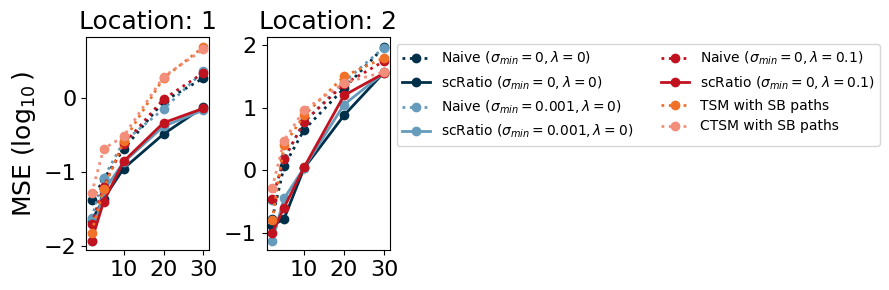

In [67]:
locs = df["loc"].unique()
fig, axes = plt.subplots(1, len(locs)-1, figsize=(3*len(locs), 3))

#780000
#C1121F
#FDF0D5
#003049
#669BBC
#F28E79
#001F36
#B7472F
#F07229

colors = {"noise on path": "#C1121F", "noise at data": "#669BBC", "deterministic path": "#003049", "CTSM_TwoSB": "#F28E79", "TSM_TwoSB": "#F07229"}
label_suffixes = {
    "noise on path": rf" $(\sigma_{{min}} = 0, \lambda = 0.1)$",
    "noise at data": rf" $(\sigma_{{min}} = 0.001, \lambda = 0)$",
    "deterministic path": rf" $(\sigma_{{min}} = 0, \lambda = 0)$",
    "CTSM_TwoSB": "CTSM with SB paths",
    "TSM_TwoSB": "TSM with SB paths"
}

if len(locs) == 1:
    axes = [axes]

for idx, loc in enumerate(locs):
    if idx == 2:
        continue
    loc_data = df[df["loc"] == loc]
        
    for scheduler_type in loc_data.scheduler_type.unique():
        subset = loc_data[loc_data.scheduler_type == scheduler_type]
        subset = subset.sort_values('num_dims')
        
        if "TSM" in scheduler_type:
            try:
                axes[idx].plot(
                    subset['num_dims'], 
                    np.log10(subset['mean_value']), 
                    marker='o',
                    label=label_suffixes[scheduler_type],
                    linestyle=":",
                    linewidth=2,
                    color=colors[scheduler_type]
                )
            except:
                continue
        else:
            axes[idx].plot(
                subset[subset.score_type == "naive"]['num_dims'], 
                np.log10(subset[subset.score_type == "naive"]['mean_value']), 
                marker='o',
                label="Naive" + label_suffixes[scheduler_type],
                linestyle=":",
                linewidth=2,
                color=colors[scheduler_type]
            )
    
            axes[idx].plot(
                subset[subset.score_type == "rl"]['num_dims'], 
                np.log10(subset[subset.score_type == "rl"]['mean_value']), 
                marker='o',
                label="scRatio" + label_suffixes[scheduler_type],
                linewidth=2,
                color=colors[scheduler_type]
            )

    # axes[idx].set_xlabel('Dimensionality', fontsize=18)
    if idx == 0:
        axes[idx].set_ylabel(r'MSE ($\log_{{10}}$)', fontsize=18)
    axes[idx].set_title(f'Location: {loc}', fontsize=18)
    axes[idx].grid(visible=False)
    axes[idx].tick_params(labelsize=16)
    if idx == 1:
        # axes[idx].legend(bbox_to_anchor=(1.1, 1.05))
        axes[idx].legend(bbox_to_anchor=(1, 1), ncol=2)

plt.tight_layout()
plt.savefig("saved_plots/legend.svg", dpi=300, bbox_inches="tight")
plt.show()

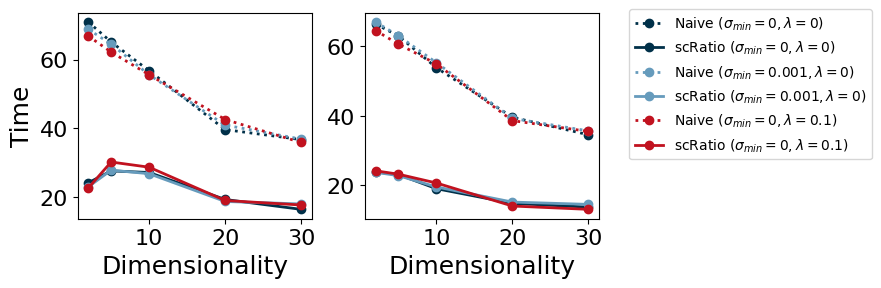

In [44]:
locs = df["loc"].unique()
fig, axes = plt.subplots(1, len(locs)-1, figsize=(3*len(locs), 3))

colors = {"noise on path": "#C1121F", "noise at data": "#669BBC", "deterministic path": "#003049"}
label_suffixes = {
    "noise on path": rf" $(\sigma_{{min}} = 0, \lambda = 0.1)$",
    "noise at data": rf" $(\sigma_{{min}} = 0.001, \lambda = 0)$",
    "deterministic path": rf" $(\sigma_{{min}} = 0, \lambda = 0)$"
}

if len(locs) == 1:
    axes = [axes]

for idx, loc in enumerate(locs):
    if idx == 2:
        continue
    loc_data = df[df["loc"] == loc]
        
    for scheduler_type in loc_data.scheduler_type.unique():
        if "TSM" in scheduler_type:
            continue
        else:
            subset = loc_data[loc_data.scheduler_type == scheduler_type]
            subset = subset.sort_values('num_dims')
            
            axes[idx].plot(
                subset[subset.score_type == "naive"]['num_dims'], 
                subset[subset.score_type == "naive"]['time'].apply(np.mean), 
                marker='o',
                label="Naive" + label_suffixes[scheduler_type],
                linestyle=":",
                linewidth=2,
                color=colors[scheduler_type]
            )
    
            axes[idx].plot(
                subset[subset.score_type == "rl"]['num_dims'], 
                subset[subset.score_type == "rl"]['time'].apply(np.mean), 
                marker='o',
                label="scRatio" + label_suffixes[scheduler_type],
                linewidth=2,
                color=colors[scheduler_type]
            )

    axes[idx].set_xlabel('Dimensionality', fontsize=18)
    if idx == 0:
        axes[idx].set_ylabel('Time', fontsize=18)
    # axes[idx].set_title(f'Location: {loc}', fontsize=18)
    axes[idx].grid(visible=False)
    axes[idx].tick_params(labelsize=16)
    if idx == 1:
        axes[idx].legend(bbox_to_anchor=(1.1, 1.05))

plt.tight_layout()
plt.savefig("saved_plots/time_plot.svg", dpi=300, bbox_inches="tight")
plt.show()

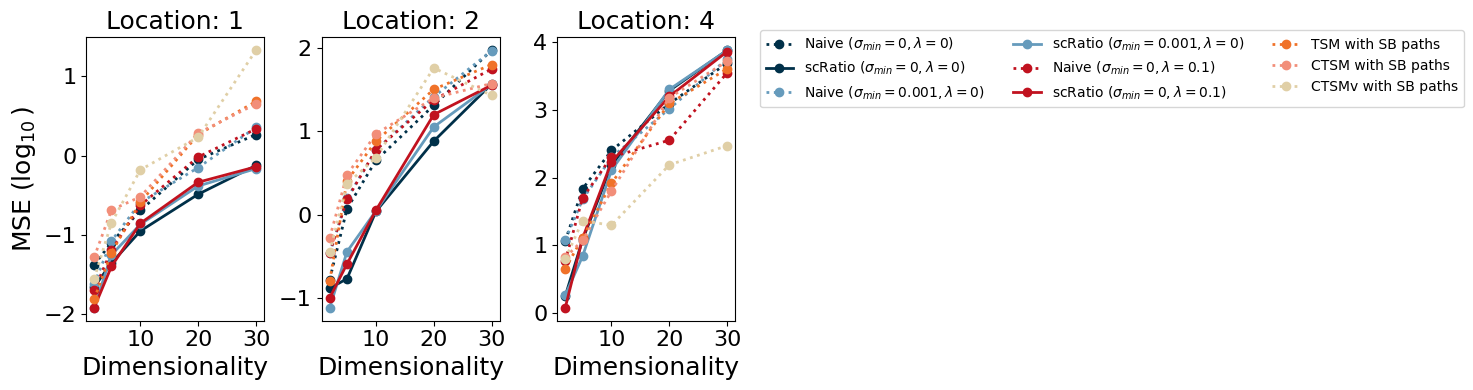

In [72]:
locs = df["loc"].unique()
fig, axes = plt.subplots(1, len(locs), figsize=(5*len(locs), 4))

colors = {"noise on path": "#C1121F", "noise at data": "#669BBC", "deterministic path": "#003049", "CTSM_TwoSB": "#F28E79", "TSM_TwoSB": "#F07229", "CTSMv_TwoSB": "#E0CFA6"}
label_suffixes = {
    "noise on path": rf" $(\sigma_{{min}} = 0, \lambda = 0.1)$",
    "noise at data": rf" $(\sigma_{{min}} = 0.001, \lambda = 0)$",
    "deterministic path": rf" $(\sigma_{{min}} = 0, \lambda = 0)$",
    "CTSM_TwoSB": "CTSM with SB paths",
    "TSM_TwoSB": "TSM with SB paths",
    "CTSMv_TwoSB": "CTSMv with SB paths"
}

if len(locs) == 1:
    axes = [axes]

for idx, loc in enumerate(locs):
    loc_data = df[df["loc"] == loc]
        
    for scheduler_type in loc_data.scheduler_type.unique():
        subset = loc_data[loc_data.scheduler_type == scheduler_type]
        subset = subset.sort_values('num_dims')
        
        if "TSM" in scheduler_type:
            try:
                axes[idx].plot(
                    subset['num_dims'], 
                    np.log10(subset['mean_value']), 
                    marker='o',
                    label=label_suffixes[scheduler_type],
                    linestyle=":",
                    linewidth=2,
                    color=colors[scheduler_type]
                )
            except:
                continue
        else:
            axes[idx].plot(
                subset[subset.score_type == "naive"]['num_dims'], 
                np.log10(subset[subset.score_type == "naive"]['mean_value']), 
                marker='o',
                label="Naive" + label_suffixes[scheduler_type],
                linestyle=":",
                linewidth=2,
                color=colors[scheduler_type]
            )
    
            axes[idx].plot(
                subset[subset.score_type == "rl"]['num_dims'], 
                np.log10(subset[subset.score_type == "rl"]['mean_value']), 
                marker='o',
                label="scRatio" + label_suffixes[scheduler_type],
                linewidth=2,
                color=colors[scheduler_type]
            )

    axes[idx].set_xlabel('Dimensionality', fontsize=18)
    if idx == 0:
        axes[idx].set_ylabel(r'MSE ($\log_{{10}}$)', fontsize=18)
    axes[idx].set_title(f'Location: {loc}', fontsize=18)
    axes[idx].grid(visible=False)
    axes[idx].tick_params(labelsize=16)
    if idx == 2:
        axes[idx].legend(bbox_to_anchor=(1.1, 1.05), ncol=3)

plt.tight_layout()
plt.savefig("saved_plots/legend_full.svg", dpi=300, bbox_inches="tight")
plt.show()